<a href="https://colab.research.google.com/github/bruacosta/Data/blob/main/Projeto_Quantum_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [635]:
# # A QuantumFinance está acompanhando
# um crescimento de inadimplência entre seus clientes e solicita a consultoria para desenvolver uma análise com base na sua carteira atual de clientes.

# # Para que a QuantumFinance tome decisões mais precisas sobre concessões de crédito, ela precisa aprimorar seu modelo de crédito.

# # Com o objeto de trazer novos clientes com o perfil de baixo risco de crédito desenvolva um modelo de Credit Scoring.

# # Desafio: Desenvolver o modelo preditivo mediante uso do valor target disponível
# na base de dados “Base_ScoreCredito_QuantumFinance.csv” e criar um simulador do modelo para os analistas de créditos e gerentes de conta.

In [636]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import scipy as stats



import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [637]:
df_score = pd.read_csv('Base_ScoreCredito_QuantumFinance.csv', sep=';')
df_score.head()

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476


In [638]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10127 non-null  int64 
 1   idade                10127 non-null  int64 
 2   sexo                 10127 non-null  object
 3   estado_civil         10127 non-null  object
 4   escola               10127 non-null  object
 5   Qte_dependentes      10127 non-null  int64 
 6   tempo_ultimoservico  10127 non-null  int64 
 7   trabalha             10127 non-null  int64 
 8   vl_salario_mil       10127 non-null  object
 9   reg_moradia          10127 non-null  int64 
 10  casa_propria         10127 non-null  int64 
 11  vl_imovel_em_mil     10127 non-null  int64 
 12  Qte_cartoes          10127 non-null  int64 
 13  Qte_carros           10127 non-null  int64 
 14  SCORE_CREDITO        10127 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.2+ MB


In [639]:
#Organizando as variáveis categóricas [sexo]

df_score['sexo'] = pd.get_dummies(df_score['sexo'],drop_first=True)



In [640]:
#Organizando as variáveis categóricas [estado_civil]
df_score = pd.get_dummies(df_score, columns=['estado_civil'],drop_first=True)

In [641]:
df_score.head()

,id,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,708082083,45,False,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778,False,False,False
1,708083283,58,True,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3",False,False,True
2,708084558,46,True,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401,True,False,False
3,708085458,34,False,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4",False,False,True
4,708086958,49,False,mestrado,2,36,0,0,3,1,437,1,2,476,False,False,False


In [642]:
df_score['escola'].unique()

array(['graduacao', 'ensino fundam', 'doutorado', 'mestrado',
       'ensino medio'], dtype=object)

In [643]:
# #Organizando as variáveis categóricas [escolaridade]
# #Neste caso como há ordem utilizei o map

mapa = {'graduacao':3, 'ensino fundam':1, 'doutorado':5, 'mestrado':4,
       'ensino medio':2}
df_score['escola'] = df_score['escola'].map(mapa)


In [644]:
df_score['escola'].unique()

array([3, 1, 5, 4, 2])

In [645]:
#Transformando as variaveis em float

df_score['vl_salario_mil'] = (df_score['vl_salario_mil'].str.replace(',','.',regex=False).astype(float))


In [646]:
# Transformando as variaveis em float
df_score['SCORE_CREDITO'] = (df_score['SCORE_CREDITO'].str.replace(',','.',regex=False).astype(float))

In [647]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10127 non-null  int64  
 1   idade                    10127 non-null  int64  
 2   sexo                     10127 non-null  bool   
 3   escola                   10127 non-null  int64  
 4   Qte_dependentes          10127 non-null  int64  
 5   tempo_ultimoservico      10127 non-null  int64  
 6   trabalha                 10127 non-null  int64  
 7   vl_salario_mil           10127 non-null  float64
 8   reg_moradia              10127 non-null  int64  
 9   casa_propria             10127 non-null  int64  
 10  vl_imovel_em_mil         10127 non-null  int64  
 11  Qte_cartoes              10127 non-null  int64  
 12  Qte_carros               10127 non-null  int64  
 13  SCORE_CREDITO            10127 non-null  float64
 14  estado_civil_divorciad

In [648]:
df_score.describe().round(2)

,id,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.0,10127.00,10127.00,10127.00
mean,7.391776e+08,46.33,2.53,1.55,34.13,0.91,70.21,3.78,0.35,209.0,1.08,0.62,469.50
std,3.690378e+07,8.02,1.21,1.49,8.22,0.28,55.57,1.58,0.48,378.5,0.33,0.57,133.81
min,7.080821e+08,26.00,1.00,0.00,7.00,0.00,0.00,1.00,0.00,0.0,1.00,0.00,162.00
25%,7.130368e+08,41.00,2.00,0.00,30.00,1.00,21.33,3.00,0.00,0.0,1.00,0.00,375.00
50%,7.179264e+08,46.00,2.00,1.00,34.00,1.00,66.49,4.00,0.00,0.0,1.00,1.00,449.60
75%,7.731435e+08,52.00,3.00,3.00,39.00,1.00,107.54,5.00,1.00,289.0,1.00,1.00,540.90
max,8.283431e+08,73.00,5.00,5.00,57.00,1.00,233.30,6.00,1.00,1800.0,4.00,2.00,979.65


In [649]:
#Vericando valores nulos

pd.DataFrame({'Count':df_score.isnull().sum(),'Percent':df_score.isnull().sum()/len(df_score)})

,Count,Percent
id,0,0.0
idade,0,0.0
sexo,0,0.0
escola,0,0.0
Qte_dependentes,0,0.0
tempo_ultimoservico,0,0.0
trabalha,0,0.0
vl_salario_mil,0,0.0
reg_moradia,0,0.0
casa_propria,0,0.0


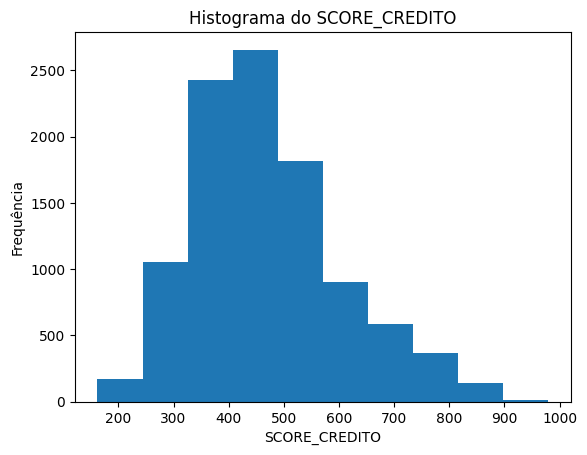

In [650]:
#verificando histograma do SCORE_CREDITO

plt.hist(df_score['SCORE_CREDITO'])
plt.title('Histograma do SCORE_CREDITO')
plt.xlabel('SCORE_CREDITO')
plt.ylabel('Frequência')
plt.show()

In [651]:
df_score.columns

Index(['id', 'idade', 'sexo', 'escola', 'Qte_dependentes',
       'tempo_ultimoservico', 'trabalha', 'vl_salario_mil', 'reg_moradia',
       'casa_propria', 'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros',
       'SCORE_CREDITO', 'estado_civil_divorciado', 'estado_civil_na',
       'estado_civil_solteiro'],
      dtype='object')

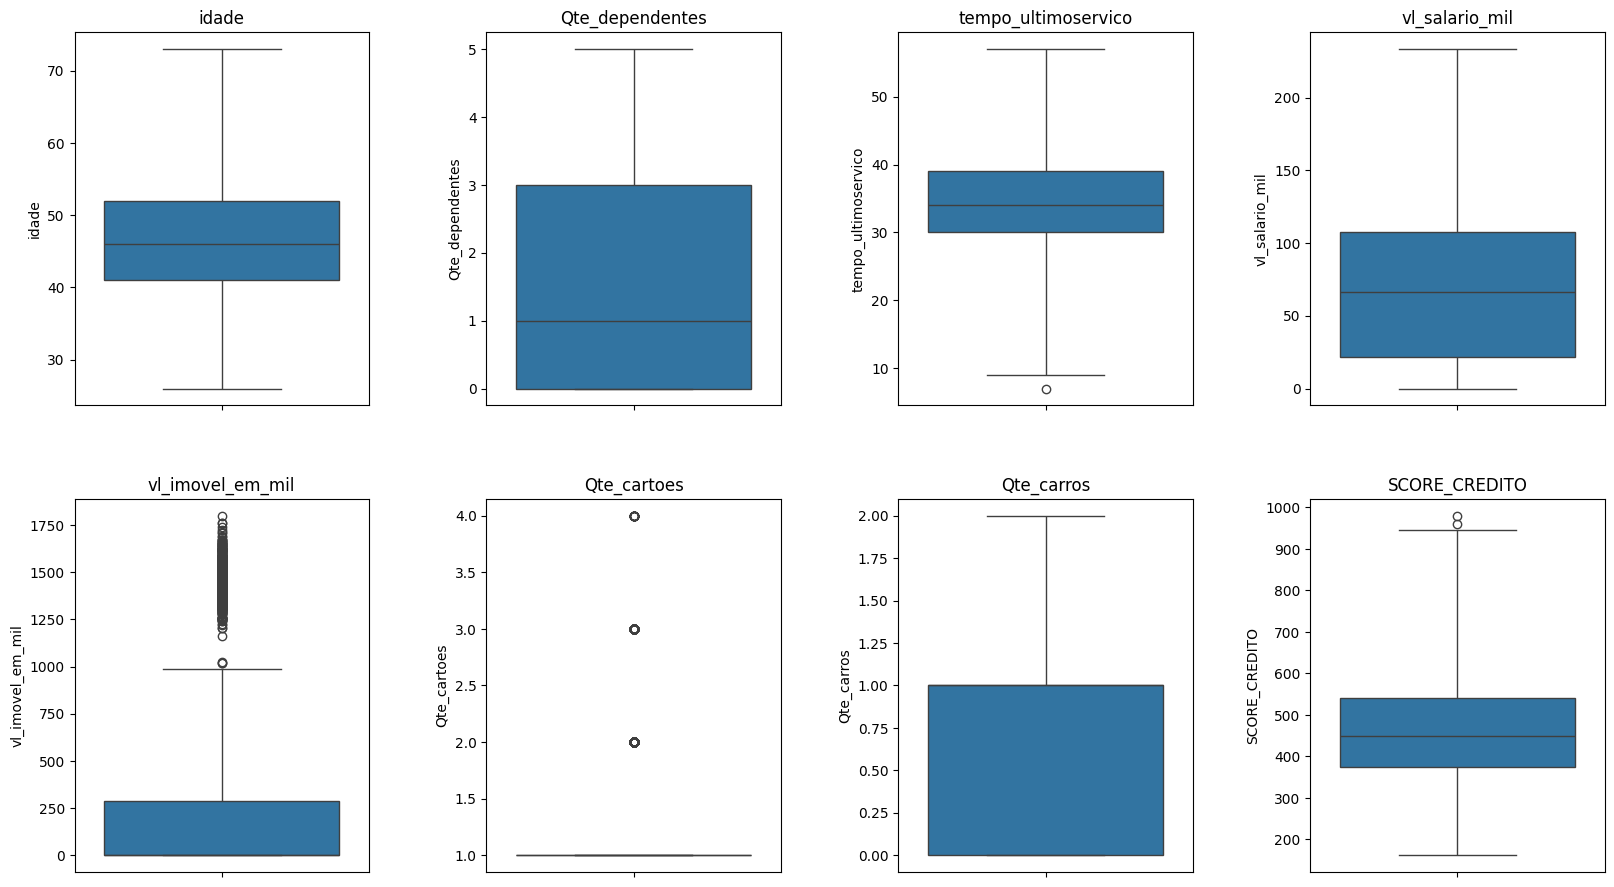

In [652]:
 # BOXPLOT Para Avaliacao das Categoricas

features = ['idade', 'Qte_dependentes',
       'tempo_ultimoservico', 'vl_salario_mil', 'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros',
       'SCORE_CREDITO']

fig,axs=plt.subplots(nrows=2, ncols=4, figsize=(18,10))

for col,ax in zip(features,axs.ravel()):
  x=df_score.loc[:,col]
  sb.boxplot(x,ax=ax,whis=2.5,orient='v')
  ax.set_title(col)
  ax.set_xlabel('')
  plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.25, wspace=0.4)


In [653]:
#Analisar melhor a variável vl_imovel_em_mil, muitos outliers
df_score['vl_imovel_em_mil'].describe()

,vl_imovel_em_mil
count,10127.000000
mean,208.999111
std,378.495229
min,0.000000
25%,0.000000
50%,0.000000
75%,289.000000
max,1800.000000


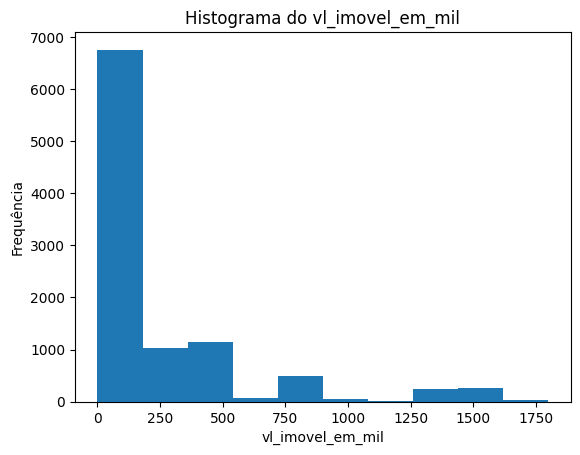

In [654]:
plt.hist(df_score['vl_imovel_em_mil'])
plt.title('Histograma do vl_imovel_em_mil')
plt.xlabel('vl_imovel_em_mil')
plt.ylabel('Frequência')
plt.show()

In [655]:
df_score['vl_imovel_em_mil'].isnull().sum()

np.int64(0)

In [656]:
#Verificando os percentils

df_score['vl_imovel_em_mil'].quantile([0.05,0.25,0.5,0.75,0.95])

,vl_imovel_em_mil
0.05,0.0
0.25,0.0
0.50,0.0
0.75,289.0
0.95,1317.7


In [657]:
#`Avaliando a quantidade de pessoas que não possuem casa propria
df_score.groupby('casa_propria')['vl_imovel_em_mil'].count()

,vl_imovel_em_mil
casa_propria,
0,6558
1,3569


In [658]:
#Avaliando o percentual que nao tem casa_propria
df_score['casa_propria'].value_counts(normalize=True)*100

,proportion
casa_propria,
0,64.757579
1,35.242421


In [659]:
#Validacao = Analisando a distriuicao de cliente que tem e não tem imóvel, entedo que não estamos falando de outliers, mas da populacao que tem imovel
# vou seguir sem remover outliers
pd.crosstab(
    df_score['casa_propria'],
    df_score['vl_imovel_em_mil'] > 0
)

vl_imovel_em_mil,False,True
casa_propria,,
0,6558,0
1,0,3569


In [660]:
# Analisando Tempo do ultimo trabalho

df_score['tempo_ultimoservico'].describe()

,tempo_ultimoservico
count,10127.000000
mean,34.133208
std,8.221428
min,7.000000
25%,30.000000
50%,34.000000
75%,39.000000
max,57.000000


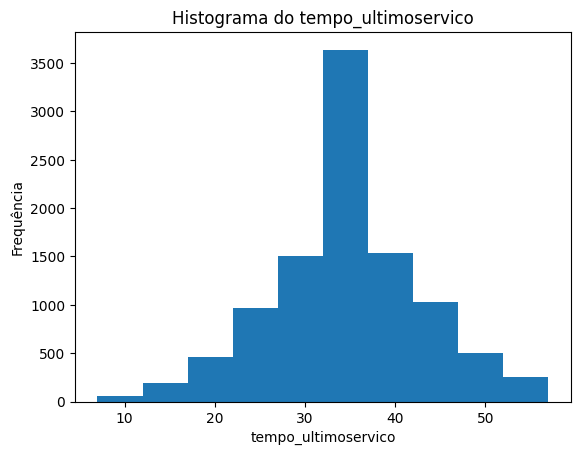

In [661]:
# Analisando Tempo do ultimo trabalho
plt.hist(df_score['tempo_ultimoservico'])
plt.title('Histograma do tempo_ultimoservico')
plt.xlabel('tempo_ultimoservico')
plt.ylabel('Frequência')
plt.show()

In [662]:
# Analisando Tempo do ultimo trabalho
# Baseado nos dados não existem erros, existe uma curva próxima a normal com concentração na média forte com cauda a esqueda e direita.
# Não considero outliers
df_score['tempo_ultimoservico'].quantile([0.05,0.25,0.5,0.75,0.95])

,tempo_ultimoservico
0.05,20.0
0.25,30.0
0.50,34.0
0.75,39.0
0.95,48.0


In [663]:
#Analisando QTD Cartoes
df_score['Qte_cartoes'].describe()

,Qte_cartoes
count,10127.000000
mean,1.083638
std,0.333784
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


In [664]:
df_score['Qte_cartoes'].quantile([0.05,0.25,0.5,0.75,0.99])

,Qte_cartoes
0.05,1.0
0.25,1.0
0.50,1.0
0.75,1.0
0.99,3.0


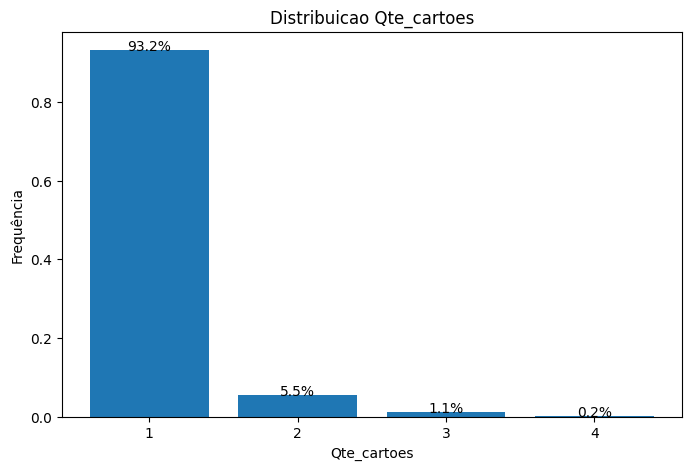

In [665]:
freq = df_score['Qte_cartoes'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,5))

plt.bar(freq.index, freq.values)
plt.xticks([1,2,3,4])

for x,y in zip(freq.index,freq.values):
  plt.text(x,y,f'{y:.1%}',
  ha='center')


plt.title('Distribuicao Qte_cartoes')
plt.xlabel('Qte_cartoes')
plt.ylabel('Frequência')
plt.show()

In [666]:
pd.crosstab(
    df_score['Qte_cartoes'],
    df_score['SCORE_CREDITO'] > 736,normalize=True
)*100

SCORE_CREDITO,False,True
Qte_cartoes,,
1,89.937790,3.238866
2,4.167078,1.313321
3,0.809717,0.335736
4,0.098746,0.098746


In [667]:
pd.crosstab(
    df_score['Qte_cartoes'],
    df_score['casa_propria'] > 0,
    normalize=True)*100



casa_propria,False,True
Qte_cartoes,,
1,61.192851,31.983806
2,3.031500,2.448899
3,0.493730,0.651723
4,0.039498,0.157993


In [668]:
pd.crosstab(df_score['Qte_cartoes'],df_score['vl_imovel_em_mil']>500,normalize=True)*100

vl_imovel_em_mil,False,True
Qte_cartoes,,
1,82.344228,10.832428
2,3.742471,1.737928
3,0.592476,0.552977
4,0.088871,0.108621


Conclusão Análise dos Cartões- pouquíssimas pessoas tem mais de 2 cartões, o que nos leva a entender que há uma população, de 2.3%, possívelmente os mais ricos, que tem mais de dois cartões e cruzando com quem tem imovel e de maiores valores, é um grupo mto próximo.
Não vejo como outliers.

In [669]:
df_score['Qte_cartoes'].value_counts()

,count
Qte_cartoes,
1,9436
2,555
3,116
4,20


In [670]:
df_score['Qte_cartoes'].unique()

array([1, 2, 3, 4])

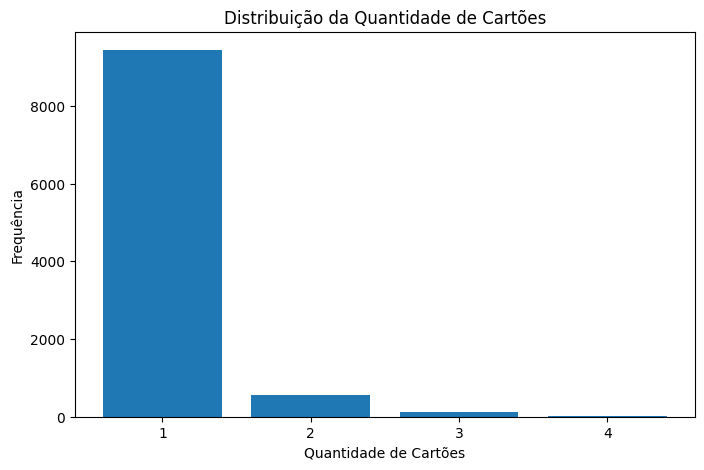

In [671]:
freq = df_score['Qte_cartoes'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(freq.index, freq.values)
plt.xticks([1,2,3,4])
plt.title('Distribuição da Quantidade de Cartões')

plt.xlabel('Quantidade de Cartões')

plt.ylabel('Frequência')

plt.show()

In [672]:
#Analisando Score
df_score['SCORE_CREDITO'].describe()

,SCORE_CREDITO
count,10127.000000
mean,469.500364
std,133.814653
min,162.000000
25%,375.000000
50%,449.600000
75%,540.900000
max,979.650000


In [673]:
df_score['SCORE_CREDITO'].quantile([0.05,0.25,0.5,0.75,0.95])
#Nota-se que menos de 5% da populacao da minha base tem mais de 736 de Score, o que nos traz uma concentração muito grande de pessoas com score 'médio'
#Isso ainda é evidenciado pelo desvio padrão, 133, muito abaixo da média 469 e a medina muito próxima a média

,SCORE_CREDITO
0.05,282.708
0.25,375.000
0.50,449.600
0.75,540.900
0.95,736.000


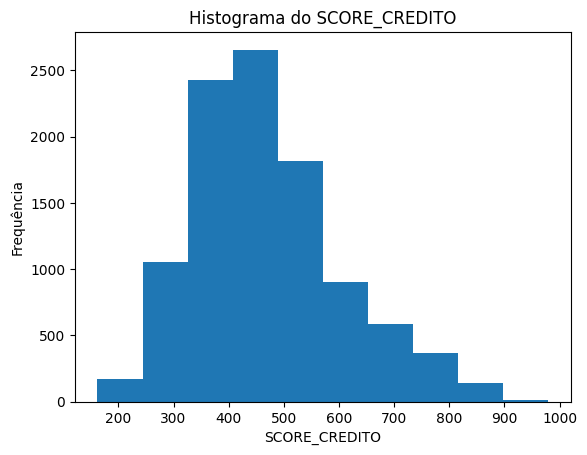

In [674]:
plt.hist(df_score['SCORE_CREDITO'])
plt.title('Histograma do SCORE_CREDITO')
plt.xlabel('SCORE_CREDITO')
plt.ylabel('Frequência')
plt.show()

#Curva próxima a normalidade, com uma concentração em score mais baixo.
#Não vejo a presença de outliers, mas sim de uma parte da população

In [675]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10127 non-null  int64  
 1   idade                    10127 non-null  int64  
 2   sexo                     10127 non-null  bool   
 3   escola                   10127 non-null  int64  
 4   Qte_dependentes          10127 non-null  int64  
 5   tempo_ultimoservico      10127 non-null  int64  
 6   trabalha                 10127 non-null  int64  
 7   vl_salario_mil           10127 non-null  float64
 8   reg_moradia              10127 non-null  int64  
 9   casa_propria             10127 non-null  int64  
 10  vl_imovel_em_mil         10127 non-null  int64  
 11  Qte_cartoes              10127 non-null  int64  
 12  Qte_carros               10127 non-null  int64  
 13  SCORE_CREDITO            10127 non-null  float64
 14  estado_civil_divorciad

In [676]:
#excluindo variavel nao util

df_score = df_score.drop(['id'],axis=1)

In [677]:
df_score.head()

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,45,False,3,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False
1,58,True,1,0,44,1,66.557645,3,0,0,1,0,276.3,False,False,True
2,46,True,5,3,35,1,123.681821,6,0,0,1,1,401.0,True,False,False
3,34,False,4,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,True
4,49,False,4,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False


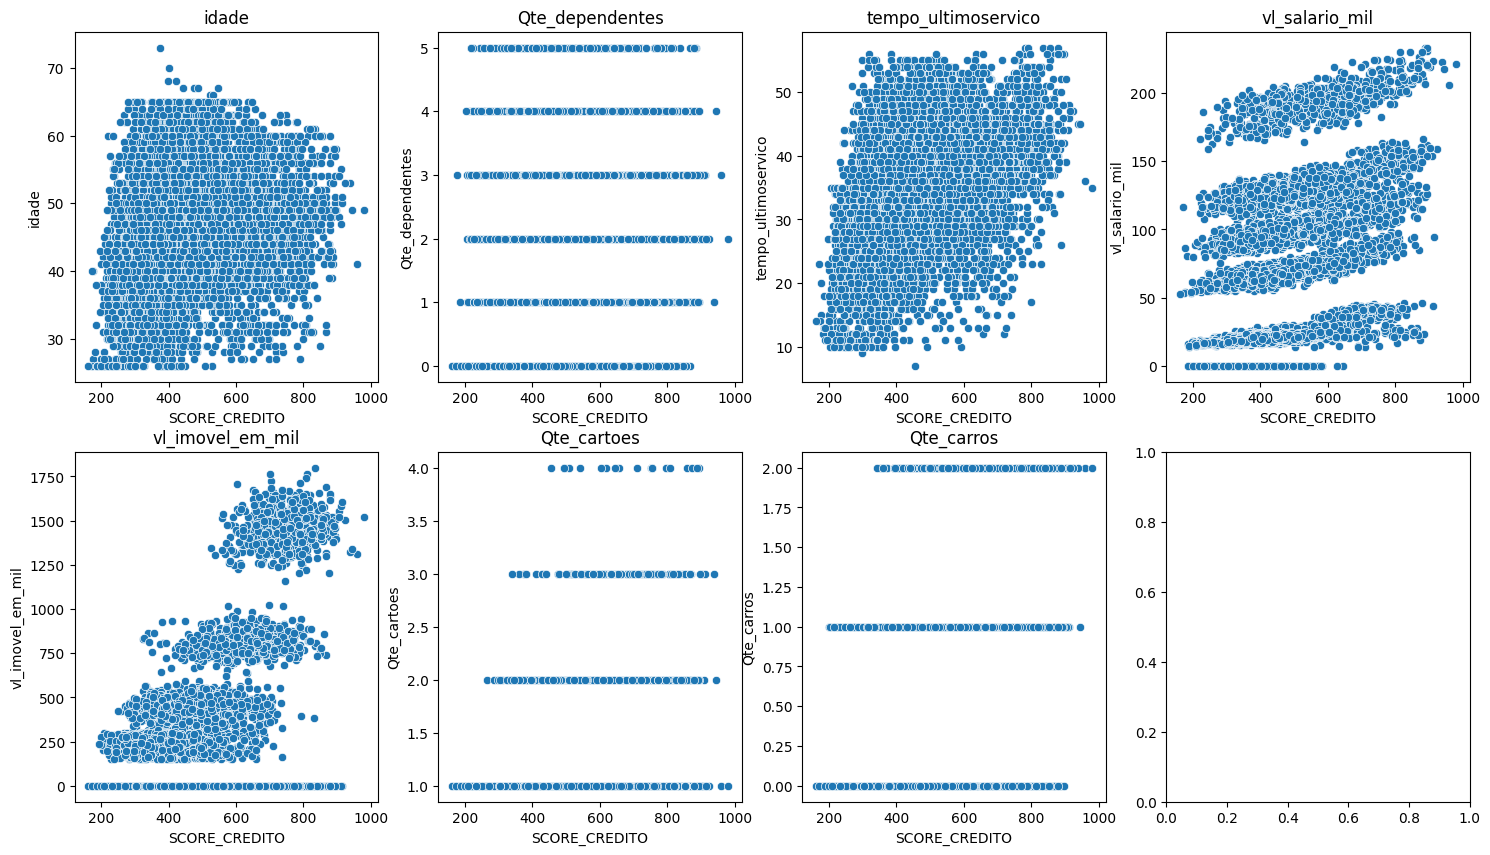

In [678]:

fig,axs=plt.subplots(nrows=2, ncols=4, figsize=(18,10))

corr_quant = ['idade', 'Qte_dependentes',
       'tempo_ultimoservico', 'vl_salario_mil', 'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros']

for col,ax in zip(corr_quant,axs.ravel()):
  sb.scatterplot(x=df_score['SCORE_CREDITO'],y=df_score[col],ax=ax)
  ax.set_title(col)
  ax.set_xlabel('SCORE_CREDITO')
  ax.set_ylabel(col)
plt.show()



Com base nos gráficos acima, pude notar que:
- vl_imovel_em_mil - Estamos falando grupos de pessoas, provavelmente classes da população, o que confirma hipóte de que não estamos falando de outliers.
- QTD_Cartoes - Não se tratam de um erro, uma parte da população tem mais de 1 cartao, apensar de ser pequena, é uma parte.
- vl_salario_mil - Estamos falando de grupos de população, sendo assim, não são outliers.

Olhando como um todo entendo que não devo remover e sim seguir para um cenário A de regressão.

In [679]:
#Correlacao pearson

df_score.corr(method='pearson',numeric_only=True)['SCORE_CREDITO'].round(2)

,SCORE_CREDITO
idade,0.21
sexo,0.22
escola,0.15
Qte_dependentes,0.10
tempo_ultimoservico,0.38
trabalha,0.23
vl_salario_mil,0.41
reg_moradia,-0.31
casa_propria,0.25
vl_imovel_em_mil,0.54


<Axes: >

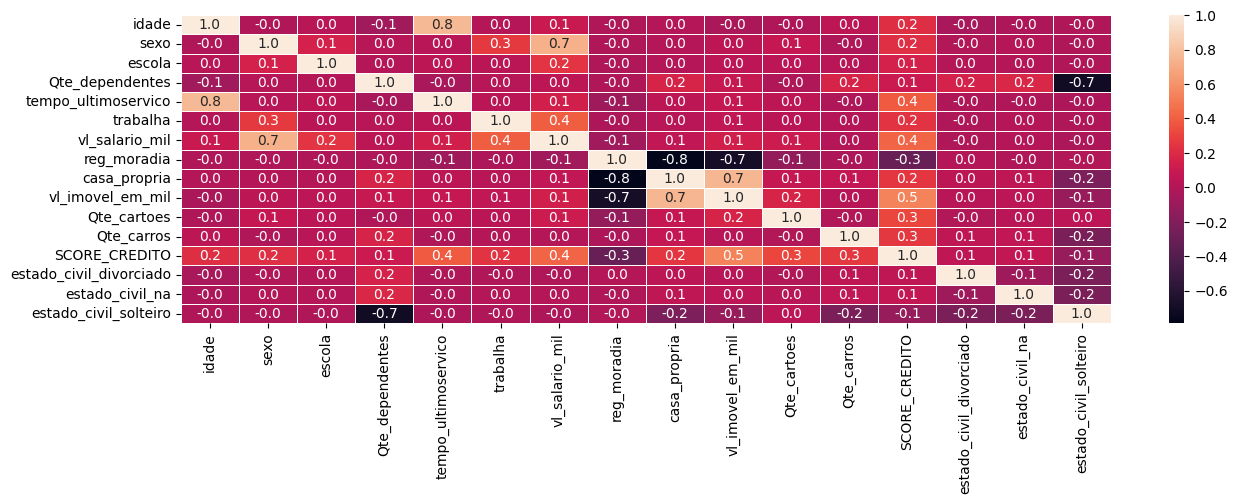

In [680]:
#mapa de calor - Score nao tem correlacao com nenhuma variável individualmente.
plt.figure(figsize=(15,4))
sb.heatmap(df_score.corr(),annot=True,fmt='.1f',linewidth=0.5)

In [681]:
#Percentual de QTD Carros

df_score['Qte_carros'].value_counts(normalize=True)*100

,proportion
Qte_carros,
1,53.352424
0,42.154636
2,4.492940


In [682]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    10127 non-null  int64  
 1   sexo                     10127 non-null  bool   
 2   escola                   10127 non-null  int64  
 3   Qte_dependentes          10127 non-null  int64  
 4   tempo_ultimoservico      10127 non-null  int64  
 5   trabalha                 10127 non-null  int64  
 6   vl_salario_mil           10127 non-null  float64
 7   reg_moradia              10127 non-null  int64  
 8   casa_propria             10127 non-null  int64  
 9   vl_imovel_em_mil         10127 non-null  int64  
 10  Qte_cartoes              10127 non-null  int64  
 11  Qte_carros               10127 non-null  int64  
 12  SCORE_CREDITO            10127 non-null  float64
 13  estado_civil_divorciado  10127 non-null  bool   
 14  estado_civil_na       

In [683]:
df_score.head()

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,45,False,3,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False
1,58,True,1,0,44,1,66.557645,3,0,0,1,0,276.3,False,False,True
2,46,True,5,3,35,1,123.681821,6,0,0,1,1,401.0,True,False,False
3,34,False,4,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,True
4,49,False,4,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False


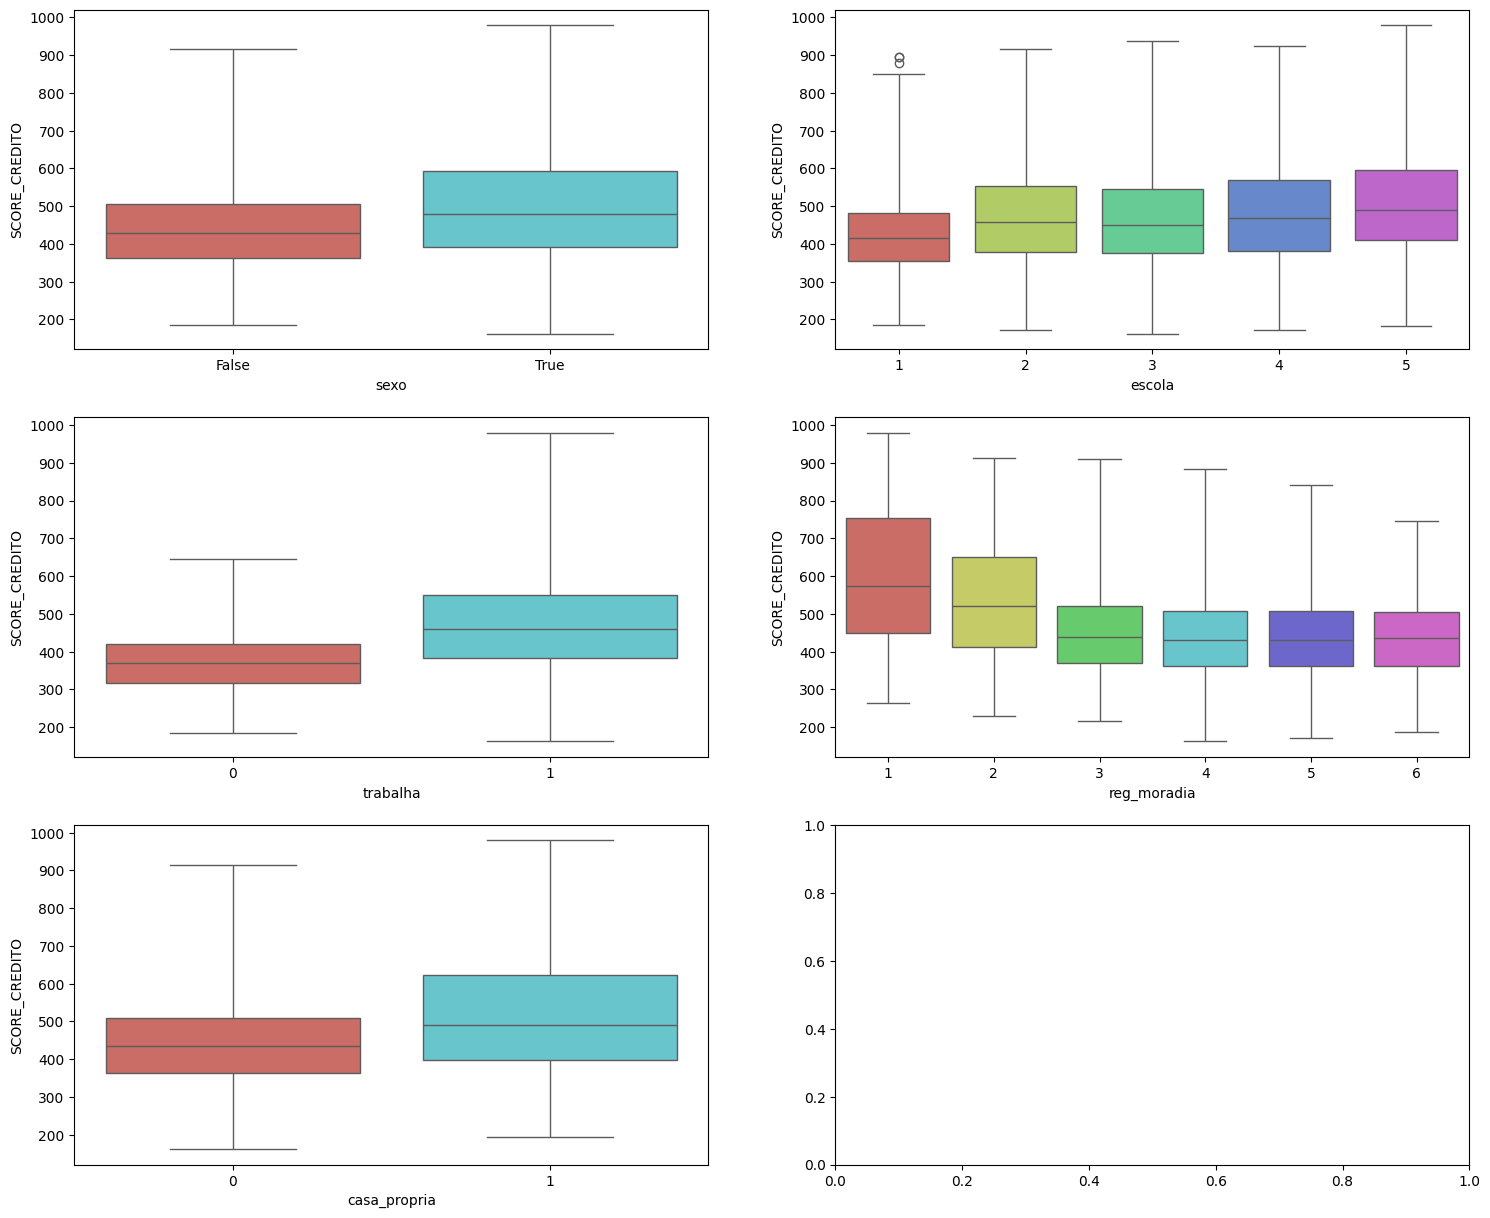

In [684]:
# Boxplot da variável Score versus variaveis categoricas

cols = 'sexo', 'escola','trabalha', 'reg_moradia', 'casa_propria'

fig,axs=plt.subplots(nrows=3, ncols=2, figsize=(18,15))

for col,ax in zip(cols,axs.ravel()):
  sb.boxplot(x=col, y='SCORE_CREDITO', data=df_score, whis =3.0, ax=ax, palette='hls');
  ax.set_xlabel(col)
  ax.set_ylabel('SCORE_CREDITO')
plt.show()


In [685]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    10127 non-null  int64  
 1   sexo                     10127 non-null  bool   
 2   escola                   10127 non-null  int64  
 3   Qte_dependentes          10127 non-null  int64  
 4   tempo_ultimoservico      10127 non-null  int64  
 5   trabalha                 10127 non-null  int64  
 6   vl_salario_mil           10127 non-null  float64
 7   reg_moradia              10127 non-null  int64  
 8   casa_propria             10127 non-null  int64  
 9   vl_imovel_em_mil         10127 non-null  int64  
 10  Qte_cartoes              10127 non-null  int64  
 11  Qte_carros               10127 non-null  int64  
 12  SCORE_CREDITO            10127 non-null  float64
 13  estado_civil_divorciado  10127 non-null  bool   
 14  estado_civil_na       

Realizando o t-student para avaliar se há relação entre a variável Score e sexo

H0= O score médio é igual entre os sexos
H1= O score médio é diferente entre os sexos

In [686]:
from scipy.stats import ttest_ind

In [687]:
# Analisando e comprovanto Score e sexo - t student (Uma quanti e uma categorica de dois grupos)

df_score.groupby('sexo')['SCORE_CREDITO'].agg(
    ['count','mean','median','std']
)


,count,mean,median,std
sexo,,,,
False,5358,442.007309,429.3,116.336567
True,4769,500.388976,480.6,144.978192


In [688]:
grupo1 = df_score[df_score['sexo']==False]['SCORE_CREDITO']

grupo2 = df_score[df_score['sexo']==True]['SCORE_CREDITO']

t_stat, p_valor = ttest_ind(

    grupo1,

    grupo2,

    equal_var=False

)

print(f't={t_stat:.3f}')

print(f'p={p_valor:.5f}')

t=-22.172
p=0.00000


T-student test - Resultado p<0,05, então rejeito H0, ou seja, há evidências estatísticas de que o score médio difere entre os sexos.
Existe evidência de associação entre sexo e score.

Realizando o t-student para avaliar se há relação entre a variável Score e Trabalha
Pergunta: O score é diferente entre quem trabalha e não trabalha?

H0= O score médio é igual entre os que trabalham
H1= O score médio é diferente entre os que trabalham ou nao

In [689]:
# Análise dos grupos
df_score.groupby('trabalha')['SCORE_CREDITO'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
trabalha,,,,
0,892,368.502646,370.24,78.933030
1,9235,479.255639,460.80,133.993967


In [690]:
#Analisando Score x Trabalha -  t student (Uma quanti e uma categorica de dois grupos)

grupo1 = df_score[df_score['trabalha']==False]['SCORE_CREDITO']

grupo2 = df_score[df_score['trabalha']==True]['SCORE_CREDITO']

t_stat, p_valor = ttest_ind(

    grupo1,

    grupo2,

    equal_var=False

)

print(f't={t_stat:.3f}')

print(f'p={p_valor:.5f}')

t=-37.064
p=0.00000


T-student test - Resultado p<0,05, então rejeito H0, ou seja, há evidências estatísticas de que o score médio difere entre os que trabalham.
Existe evidência de associação entre trabalha e score.

Realizando o t-student para avaliar se há relação entre a variável Score e Casa Própria
Pergunta: O score é diferente entre quem tem ou não casa própria?

H0= O score médio é igual entre os que tem casa propria ou nao
H1= O score médio é diferente entre os que tem casa propria ou nao

In [691]:
df_score.columns

Index(['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia', 'casa_propria',
       'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros', 'SCORE_CREDITO',
       'estado_civil_divorciado', 'estado_civil_na', 'estado_civil_solteiro'],
      dtype='object')

In [692]:
# Análise dos grupos
df_score.groupby('casa_propria')['SCORE_CREDITO'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
casa_propria,,,,
0,6558,444.860351,434.7,115.862767
1,3569,514.776129,491.0,151.598199


In [693]:
# Analisando Score x Casa própria -  t student (Uma quanti e uma categorica de dois grupos)

#Analisando Score x Trabalha -  t student (Uma quanti e uma categorica de dois grupos)

grupo1 = df_score[df_score['casa_propria']==False]['SCORE_CREDITO']

grupo2 = df_score[df_score['casa_propria']==True]['SCORE_CREDITO']

t_stat, p_valor = ttest_ind(

    grupo1,

    grupo2,

    equal_var=False

)

print(f't={t_stat:.3f}')

print(f'p={p_valor:.5f}')

t=-24.000
p=0.00000


T-student test - Resultado p<0,05, então rejeito H0, ou seja, há evidências estatísticas de que o score médio difere entre os que tem casa propria e não.
Existe evidência de associação entre casa_propria e score.

Realizando o Qui-quadrado para avaliar se há relação entre a variável Faixa de SCORE e região
Pergunta: Existe Associação entre a Fx_score e a escolaridade?

H0= Não existe associação
H1= Existe associação



In [694]:
df_score['SCORE_CREDITO'].quantile([0.25,0.5,0.75,0.95])

,SCORE_CREDITO
0.25,375.0
0.50,449.6
0.75,540.9
0.95,736.0


In [695]:
df_score['fx_score'] = pd.cut(df_score['SCORE_CREDITO'],bins=[0,375,450,600,1000],labels=['RUIM','MEDIO','BOM','EXCELENTE'])

In [696]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [697]:
pd.crosstab(df_score['escola'],df_score['fx_score'])

fx_score,RUIM,MEDIO,BOM,EXCELENTE
escola,,,,
1,736,684,692,171
2,791,810,1154,597
3,513,527,706,348
4,375,363,573,328
5,130,154,294,181


In [698]:
df_score.groupby('escola')['fx_score'].value_counts(normalize=True)*100

escola  fx_score 
1       RUIM         32.238283
        BOM          30.310994
        MEDIO        29.960578
        EXCELENTE     7.490145
2       BOM          34.427208
        MEDIO        24.164678
        RUIM         23.597852
        EXCELENTE    17.810263
3       BOM          33.715377
        MEDIO        25.167144
        RUIM         24.498567
        EXCELENTE    16.618911
4       BOM          34.960342
        RUIM         22.879805
        MEDIO        22.147651
        EXCELENTE    20.012203
5       BOM          38.735178
        EXCELENTE    23.847167
        MEDIO        20.289855
        RUIM         17.127800
Name: proportion, dtype: float64

In [699]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [700]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2
!pip install researchpy
import researchpy

In [701]:
#Analisando Score x escolaridade - Teste QUI- Quadrado

results1 = researchpy.crosstab(df_score['fx_score'],df_score['escola'], test='chi-square')
results1


(          escola                              
 escola         1     2     3     4    5    All
 fx_score                                      
 RUIM         736   791   513   375  130   2545
 MEDIO        684   810   527   363  154   2538
 BOM          692  1154   706   573  294   3419
 EXCELENTE    171   597   348   328  181   1625
 All         2283  3352  2094  1639  759  10127,
               Chi-square test   results
 0  Pearson Chi-square (12) =   278.0905
 1                  p-value =     0.0000
 2               Cramer's V =     0.0957)

Conforme teste de Qui-Quadrado o resultado do p-value é 0.000, ou seja, p-value,0.05, o que mostra que há associação entre fx_score e escolaridade, mas analisando o Cramer's, há indícios de que essa associação é fraca.

Realizando o Qui-quadrado para avaliar se há relação entre a variável Faixa de SCORE e região
Pergunta: Existe Associação entre a Fx_score e a regiao de moradia?

H0= Não existe associação
H1= Existe associação


In [702]:
df_score.groupby('reg_moradia')['fx_score'].value_counts(normalize=True)*100

reg_moradia  fx_score 
1            EXCELENTE    46.572770
             BOM          27.699531
             MEDIO        15.962441
             RUIM          9.765258
2            EXCELENTE    34.536082
             BOM          31.701031
             MEDIO        18.298969
             RUIM         15.463918
3            BOM          33.629893
             MEDIO        28.425267
             RUIM         26.734875
             EXCELENTE    11.209964
4            BOM          34.061362
             RUIM         30.473219
             MEDIO        26.417057
             EXCELENTE     9.048362
5            BOM          35.820896
             RUIM         28.997868
             MEDIO        26.972281
             EXCELENTE     8.208955
6            BOM          36.304700
             RUIM         28.633171
             MEDIO        27.120475
             EXCELENTE     7.941653
Name: proportion, dtype: float64

In [703]:
#Analisando por Qui-Quadrado associação entre fx_score e regiao
results2 = researchpy.crosstab(df_score['fx_score'],df_score['reg_moradia'], test='chi-square')
results2

(            reg_moradia                                     
 reg_moradia           1     2     3     4     5     6    All
 fx_score                                                    
 RUIM                104   180   601   586   544   530   2545
 MEDIO               170   213   639   508   506   502   2538
 BOM                 295   369   756   655   672   672   3419
 EXCELENTE           496   402   252   174   154   147   1625
 All                1065  1164  2248  1923  1876  1851  10127,
               Chi-square test    results
 0  Pearson Chi-square (15) =   1386.0668
 1                  p-value =      0.0000
 2               Cramer's V =      0.2136)

Conforme teste de Qui-Quadrado há associação entre Regiao e fx_score, contudo devido ao Cramer's 0,21, podemos considerar essas associação como fraca.

In [704]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [705]:
colunas = df_score.columns[0:11].tolist()+df_score.columns[13:16].tolist()
X = df_score[colunas]

y = df_score['SCORE_CREDITO']

In [706]:
X

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,45,False,3,3,40,1,40.089665,3,0,0,1,False,False,False
1,58,True,1,0,44,1,66.557645,3,0,0,1,False,False,True
2,46,True,5,3,35,1,123.681821,6,0,0,1,True,False,False
3,34,False,4,0,22,1,19.715934,6,0,0,1,False,False,True
4,49,False,4,2,36,0,0.000000,3,1,437,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,True,4,0,45,1,100.128971,4,0,0,1,False,False,False
10123,38,True,1,0,31,1,89.805996,6,0,0,1,False,False,True
10124,49,False,3,3,43,1,19.799306,3,1,252,1,False,False,False
10125,54,True,2,4,48,1,194.783176,4,0,0,1,False,False,False


In [707]:
y

,SCORE_CREDITO
0,778.0
1,276.3
2,401.0
3,347.4
4,476.0
...,...
10122,470.0
10123,432.0
10124,406.0
10125,387.0


In [708]:
# Importar as bibliotecas
from sklearn.model_selection import train_test_split

# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 20)

In [709]:
X_train

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
569,46,True,1,4,36,1,74.770090,3,1,803,2,False,False,False
6395,49,False,1,3,35,1,18.670265,3,1,177,1,True,False,False
4333,36,False,3,3,35,1,16.560803,6,0,0,1,False,False,False
7543,55,False,1,0,42,1,20.692570,4,0,0,1,False,False,True
7991,49,True,3,4,30,1,100.069583,5,0,0,2,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3915,44,False,2,4,28,1,18.276319,3,1,197,1,False,False,False
9620,65,True,5,0,54,1,76.068076,5,0,0,1,False,False,True
7068,49,True,3,2,41,1,94.736673,6,0,0,1,False,True,False
7391,63,True,3,0,48,1,139.874249,3,1,151,1,False,False,False


In [710]:
y_train

,SCORE_CREDITO
569,662.0
6395,436.0
4333,293.0
7543,432.0
7991,576.0
...,...
3915,392.0
9620,488.7
7068,315.0
7391,528.0


In [711]:
# importar bibliotecas
import statsmodels.api as sm
from scipy import stats

In [712]:
X_ = sm.add_constant(X_train)
X_

,const,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
569,1.0,46,True,1,4,36,1,74.770090,3,1,803,2,False,False,False
6395,1.0,49,False,1,3,35,1,18.670265,3,1,177,1,True,False,False
4333,1.0,36,False,3,3,35,1,16.560803,6,0,0,1,False,False,False
7543,1.0,55,False,1,0,42,1,20.692570,4,0,0,1,False,False,True
7991,1.0,49,True,3,4,30,1,100.069583,5,0,0,2,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3915,1.0,44,False,2,4,28,1,18.276319,3,1,197,1,False,False,False
9620,1.0,65,True,5,0,54,1,76.068076,5,0,0,1,False,False,True
7068,1.0,49,True,3,2,41,1,94.736673,6,0,0,1,False,True,False
7391,1.0,63,True,3,0,48,1,139.874249,3,1,151,1,False,False,False


In [713]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [714]:
X_ = X_.astype(float)

y_train = y_train.astype(float)

In [715]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [716]:

model_OLS = sm.OLS(y_train, X_).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1023.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:29:33   Log-Likelihood:                -56356.
No. Observations:                9620   AIC:                         1.127e+05
Df Residuals:                    9605   BIC:                         1.128e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [717]:
df_score.head()

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,fx_score
0,45,False,3,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False,EXCELENTE
1,58,True,1,0,44,1,66.557645,3,0,0,1,0,276.3,False,False,True,RUIM
2,46,True,5,3,35,1,123.681821,6,0,0,1,1,401.0,True,False,False,MEDIO
3,34,False,4,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,True,RUIM
4,49,False,4,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False,BOM


In [718]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [719]:
#Achei estranho esse casa_propria trazendo um coef. -107,
#imagino que como já temos uma variavel de vl_imovel_em mil, nao sobrou impacto para a casa propria.
#vou testar sem casa_propria

In [720]:
X2 = X_.drop(columns=['casa_propria'])

model_OLS2 = sm.OLS(y_train, X2).fit()

print(model_OLS2.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     942.0
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:29:34   Log-Likelihood:                -56793.
No. Observations:                9620   AIC:                         1.136e+05
Df Residuals:                    9606   BIC:                         1.137e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

A variável “casa própria” apresentou comportamento distinto da análise univariada. Embora indivíduos com casa própria possuam score médio superior, na regressão múltipla o coeficiente tornou-se negativo. Esse comportamento sugere correlação entre “casa própria” e “valor do imóvel”, indicando que parte do efeito observado é compartilhado entre ambas as variáveis. Apesar disso, a remoção da variável reduziu o poder explicativo do modelo (R² de 0,599 para 0,562), justificando sua manutenção no modelo final.

In [721]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [722]:
df_score.head()

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,fx_score
0,45,False,3,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False,EXCELENTE
1,58,True,1,0,44,1,66.557645,3,0,0,1,0,276.3,False,False,True,RUIM
2,46,True,5,3,35,1,123.681821,6,0,0,1,1,401.0,True,False,False,MEDIO
3,34,False,4,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,True,RUIM
4,49,False,4,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False,BOM


In [723]:

model_fim = sm.OLS(y_train, X2).fit()

In [724]:
#simulador
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [725]:
y_train_pred = model_fim.predict(X2)


In [726]:
y_train_pred

,0
569,642.966260
6395,444.798396
4333,441.955944
7543,425.512648
7991,511.123968
...,...
3915,401.689549
9620,529.775299
7068,514.174924
7391,543.352852


In [727]:
# Medidas de erro na amostra treino
me1   = round((y_train-y_train_pred).mean(),2)
print('Erro Médio (Mean error-ME):', me1)
mae1  = round((mean_absolute_error(y_train, y_train_pred)),2)
print('Erro Médio Absoluto (Mean Absolut Error-MAE):', mae1)
mse1  =round( (mean_squared_error(y_train, y_train_pred)),2)
print('Erro Quadrático Médio (Mean Squared Error-MSE)::', mse1)
rmse1  = round((np.sqrt(mean_squared_error(y_train, y_train_pred))),2)
print('Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE):', rmse1)
mpe1  = round(((y_train - y_train_pred)/y_train).mean(),2)
print('Erro Percentual Médio (Mean Percent Error-MPE):', mpe1)
mape1  =  round((mae1/y_train).mean(),2)
print('Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE):', mape1)

Erro Médio (Mean error-ME): -0.0
Erro Médio Absoluto (Mean Absolut Error-MAE): 68.8
Erro Quadrático Médio (Mean Squared Error-MSE):: 7859.69
Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE): 88.65
Erro Percentual Médio (Mean Percent Error-MPE): -0.04
Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE): 0.16


In [728]:
# Construção de diagnóstico para os gráficos

modelo_ajust_y = model_fim.fittedvalues # Valores do modelo ajustados na base treino

modelo_residuos = model_fim.resid # Residuos

modelo_norm_resid = model_fim.get_influence().resid_studentized_internal # Residuos normalizados

modelo_norm_resid_abs = np.sqrt(np.abs(modelo_norm_resid)) # Quadrados dos residuos normalizados

modelo_outliers = model_fim.get_influence().hat_matrix_diag # Outliers

distancia_cook = model_fim.get_influence().cooks_distance[0] # Distancia de Cook

In [729]:
modelo_ajust_y

,0
569,642.966260
6395,444.798396
4333,441.955944
7543,425.512648
7991,511.123968
...,...
3915,401.689549
9620,529.775299
7068,514.174924
7391,543.352852


In [730]:
modelo_residuos

,0
569,19.033740
6395,-8.798396
4333,-148.955944
7543,6.487352
7991,64.876032
...,...
3915,-9.689549
9620,-41.075299
7068,-199.174924
7391,-15.352852


In [731]:
modelo_norm_resid

array([ 0.2147454 , -0.09926182, -1.67997439, ..., -2.24716323,
       -0.17316646,  1.62487235])

In [732]:
distancia_cook

array([6.35759048e-06, 1.29018284e-06, 2.45049933e-04, ...,
       6.96549126e-04, 2.89897239e-06, 1.12049553e-04])

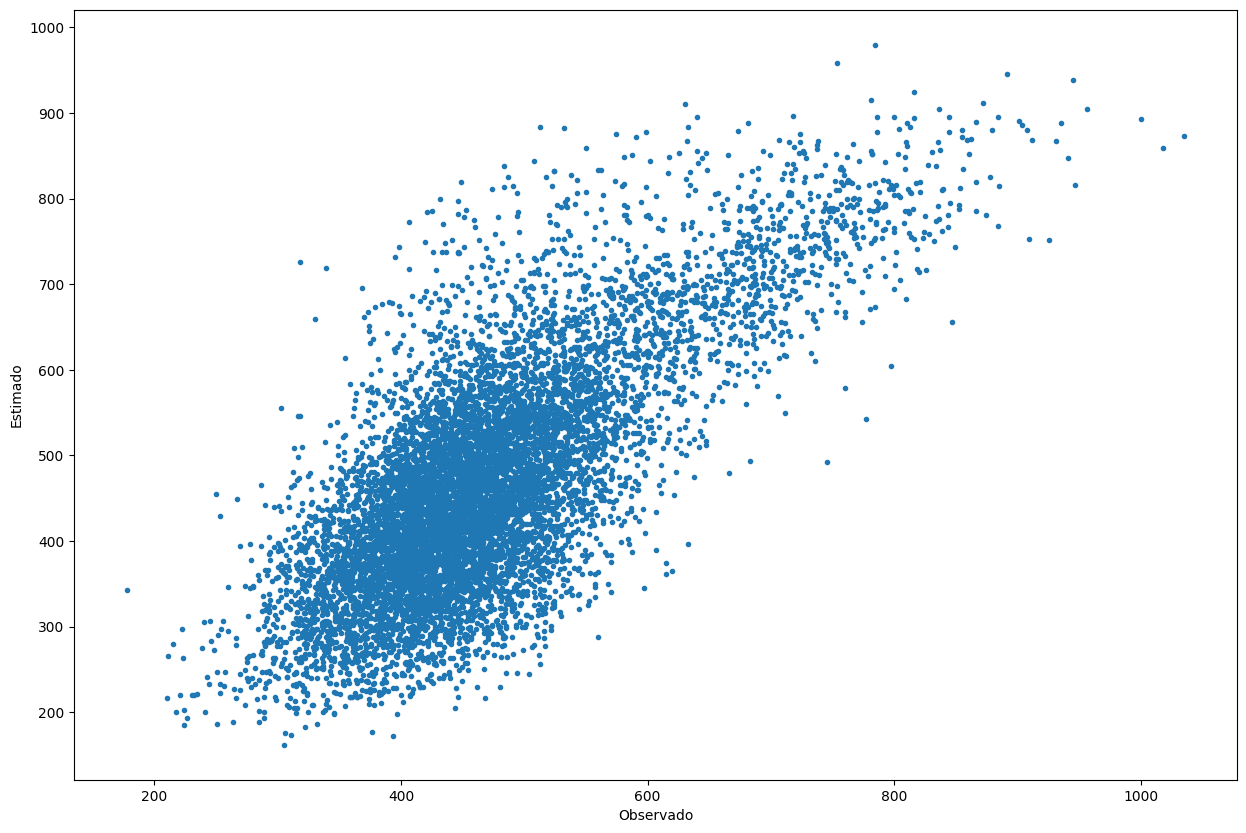

In [733]:
plt.figure(figsize=(15, 10))
plt.scatter(y_train_pred ,y_train, marker='.')
plt.xlabel("Observado")
plt.ylabel("Estimado");

In [734]:
dataframe = pd.concat([y_train, modelo_ajust_y], axis=1)

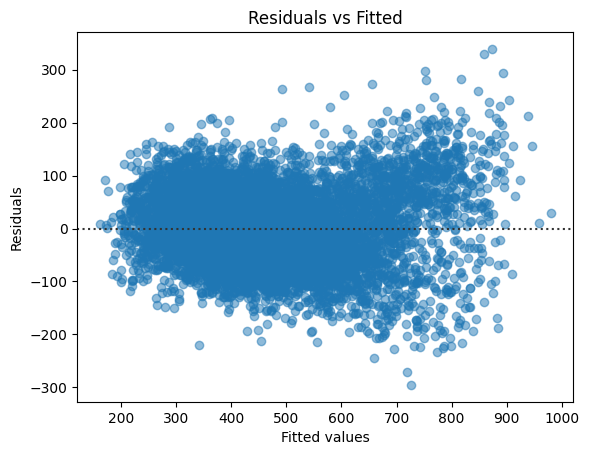

In [735]:
### Teste de Linearidade
### Nestes gráficos a presença de um padrão nos resíduos pode indicar um problema com algum aspecto do modelo linear.
plot_lm_1 = plt.figure()
plot_lm_1 = sb.residplot(data=dataframe, x=dataframe.columns[-0], y=modelo_ajust_y,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

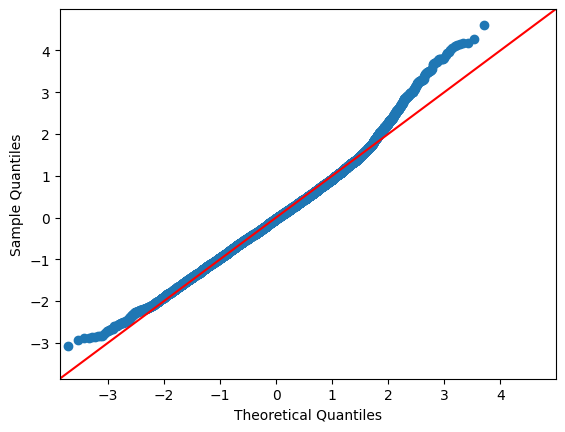

In [736]:
plot_lm_2  = sm.qqplot(modelo_norm_resid, line='45')
plt.show()

Teste de normalidade dos resíduos Shapiro-Wilk Test Teste de hipótese:

H0: Distribuição = Normal H1: Distribuição <> Normal

Erro de decisâo: 0,05 ou 5%

Critério de decisâo:
    Se p-value < erro de decisão então rejeito H0.
    Se p-value >= erro de decisão então não rejeito H0

In [737]:
shapiro_test = stats.shapiro(modelo_norm_resid)
shapiro_test
#(statistic, p-value)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9620.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.989212263289445), pvalue=np.float64(2.192285751174342e-26))

O teste de Shapiro-Wilk indicou rejeição da hipótese de normalidade dos resíduos (p < 0,05). Entretanto, considerando o grande tamanho amostral e a análise gráfica por histograma e QQ Plot, observa-se que os resíduos apresentam comportamento aproximadamente normal, com desvios mais evidentes apenas nas caudas da distribuição.

In [738]:
idx = model_fim.resid.nlargest(20).index

df_score.loc[idx]

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,fx_score
7696,36,False,2,0,13,1,40.825811,6,0,0,1,1,726.3,False,False,True,EXCELENTE
1783,28,True,5,0,12,1,104.087188,4,0,0,1,1,719.1,False,False,True,EXCELENTE
3740,39,False,2,3,34,1,23.664817,4,0,0,2,0,884.0,False,True,False,EXCELENTE
1645,38,True,3,0,35,1,114.569775,3,0,0,1,1,819.0,False,False,False,EXCELENTE
8451,36,True,2,3,17,1,111.998716,3,0,0,2,1,799.0,False,False,False,EXCELENTE
8000,36,True,4,1,23,1,110.027421,5,0,0,1,0,773.0,False,False,False,EXCELENTE
9808,41,False,2,0,37,1,40.484073,3,0,0,1,1,784.8,False,False,True,EXCELENTE
9719,38,False,1,2,37,1,37.529856,3,0,0,1,1,786.0,False,False,False,EXCELENTE
643,42,False,5,2,34,1,118.632566,3,0,0,1,0,838.0,False,False,False,EXCELENTE
4383,32,False,2,1,40,1,34.574542,3,0,0,1,1,797.0,False,False,False,EXCELENTE


In [739]:
idx = model_fim.resid.nlargest(100).index

df_score.loc[idx].describe()

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.0,100.0,100.000000,100.000000,100.000000
mean,44.390000,2.630000,1.590000,35.750000,0.99,91.737496,3.570000,0.0,0.0,1.140000,0.750000,759.344750
std,7.942845,1.284366,1.518206,8.951468,0.10,55.662726,0.987344,0.0,0.0,0.348735,0.657129,67.941647
min,28.000000,1.000000,0.000000,12.000000,0.00,0.000000,2.000000,0.0,0.0,1.000000,0.000000,613.800000
25%,39.000000,2.000000,0.000000,31.000000,1.00,39.989313,3.000000,0.0,0.0,1.000000,0.000000,705.825000
50%,44.000000,2.000000,1.000000,36.000000,1.00,101.346639,3.000000,0.0,0.0,1.000000,1.000000,760.200000
75%,50.000000,3.250000,3.000000,41.000000,1.00,130.127517,4.000000,0.0,0.0,1.000000,1.000000,808.750000
max,61.000000,5.000000,5.000000,57.000000,1.00,233.301793,6.000000,0.0,0.0,2.000000,2.000000,910.000000


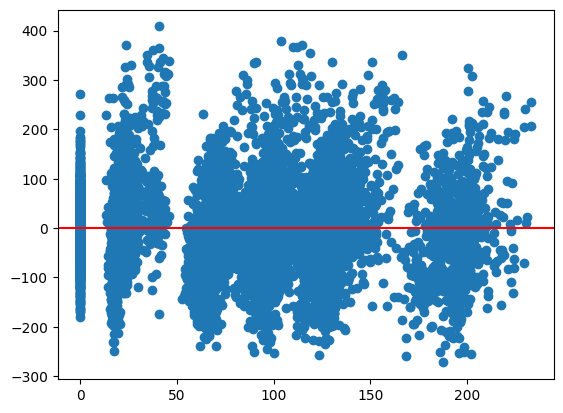

In [740]:
plt.scatter(

    X_['vl_salario_mil'],

    model_fim.resid

)

plt.axhline(0, color='red')

plt.show()

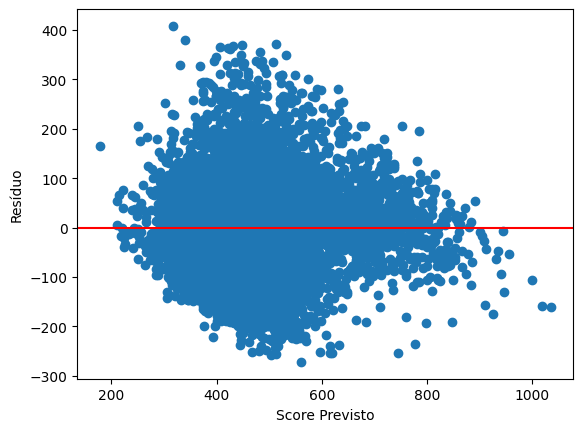

In [741]:
plt.scatter(

    model_fim.fittedvalues,

    model_fim.resid

)

plt.axhline(0,color='red')

plt.xlabel('Score Previsto')

plt.ylabel('Resíduo')

plt.show()

Os maiores resíduos positivos não parecem estar concentrados apenas nos clientes de maior renda. Portanto, a assimetria observada nos resíduos provavelmente não pode ser explicada apenas pela renda, sugerindo a existência de outros fatores ou relações não lineares não capturadas pelo modelo.”

In [742]:
# Remover do teste as mesmas colunas removidas no treino
X_test2 = X_test.drop(columns=['casa_propria'])

# Adicionar constante
X_test2_sm = sm.add_constant(X_test2, has_constant='add')

# Garantir mesma ordem de colunas do treino
X_test2_sm = X_test2_sm[model_fim.model.exog_names]



# Prever
y_pred = model_fim.predict(X_test2_sm)

In [743]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('R² teste:', r2_score(y_test, y_pred))

print('MAE teste:', mean_absolute_error(y_test, y_pred))

print('RMSE teste:', mean_squared_error(y_test, y_pred) ** 0.5)

R² teste: 0.5612369458508577
MAE teste: 68.11830553008117
RMSE teste: 89.77254722879803


In [744]:
# Utilziando Machine Learning From Scikit-learn
df_score.columns


Index(['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia', 'casa_propria',
       'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros', 'SCORE_CREDITO',
       'estado_civil_divorciado', 'estado_civil_na', 'estado_civil_solteiro',
       'fx_score'],
      dtype='object')

In [745]:
df_score.head()

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,fx_score
0,45,False,3,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False,EXCELENTE
1,58,True,1,0,44,1,66.557645,3,0,0,1,0,276.3,False,False,True,RUIM
2,46,True,5,3,35,1,123.681821,6,0,0,1,1,401.0,True,False,False,MEDIO
3,34,False,4,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,True,RUIM
4,49,False,4,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False,BOM


In [746]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idade                    10127 non-null  int64   
 1   sexo                     10127 non-null  bool    
 2   escola                   10127 non-null  int64   
 3   Qte_dependentes          10127 non-null  int64   
 4   tempo_ultimoservico      10127 non-null  int64   
 5   trabalha                 10127 non-null  int64   
 6   vl_salario_mil           10127 non-null  float64 
 7   reg_moradia              10127 non-null  int64   
 8   casa_propria             10127 non-null  int64   
 9   vl_imovel_em_mil         10127 non-null  int64   
 10  Qte_cartoes              10127 non-null  int64   
 11  Qte_carros               10127 non-null  int64   
 12  SCORE_CREDITO            10127 non-null  float64 
 13  estado_civil_divorciado  10127 non-null  bool    
 14  estado

In [747]:
df_score.drop(columns=['fx_score','casa_propria'], inplace=True)

In [748]:
df_score.columns

Index(['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia', 'vl_imovel_em_mil',
       'Qte_cartoes', 'Qte_carros', 'SCORE_CREDITO', 'estado_civil_divorciado',
       'estado_civil_na', 'estado_civil_solteiro'],
      dtype='object')

In [749]:
df_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    10127 non-null  int64  
 1   sexo                     10127 non-null  bool   
 2   escola                   10127 non-null  int64  
 3   Qte_dependentes          10127 non-null  int64  
 4   tempo_ultimoservico      10127 non-null  int64  
 5   trabalha                 10127 non-null  int64  
 6   vl_salario_mil           10127 non-null  float64
 7   reg_moradia              10127 non-null  int64  
 8   vl_imovel_em_mil         10127 non-null  int64  
 9   Qte_cartoes              10127 non-null  int64  
 10  Qte_carros               10127 non-null  int64  
 11  SCORE_CREDITO            10127 non-null  float64
 12  estado_civil_divorciado  10127 non-null  bool   
 13  estado_civil_na          10127 non-null  bool   
 14  estado_civil_solteiro 

In [750]:
X = df_score[['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia',
       'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros',
       'estado_civil_divorciado', 'estado_civil_na', 'estado_civil_solteiro']]
y = df_score[['SCORE_CREDITO']]

In [751]:
X

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,vl_imovel_em_mil,Qte_cartoes,Qte_carros,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,45,False,3,3,40,1,40.089665,3,0,1,1,False,False,False
1,58,True,1,0,44,1,66.557645,3,0,1,0,False,False,True
2,46,True,5,3,35,1,123.681821,6,0,1,1,True,False,False
3,34,False,4,0,22,1,19.715934,6,0,1,0,False,False,True
4,49,False,4,2,36,0,0.000000,3,437,1,2,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,True,4,0,45,1,100.128971,4,0,1,0,False,False,False
10123,38,True,1,0,31,1,89.805996,6,0,1,1,False,False,True
10124,49,False,3,3,43,1,19.799306,3,252,1,1,False,False,False
10125,54,True,2,4,48,1,194.783176,4,0,1,1,False,False,False


In [752]:
y

,SCORE_CREDITO
0,778.0
1,276.3
2,401.0
3,347.4
4,476.0
...,...
10122,470.0
10123,432.0
10124,406.0
10125,387.0


In [753]:
# Regressão linear múltipla
from sklearn.linear_model import LinearRegression

#Criando um Objeto de Regressão Linear
lr = LinearRegression()

In [754]:

#Separando os dados de Treino e Teste
# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 17)

In [755]:
lr.fit(X_train,y_train)

LinearRegression()

In [756]:
print('Intercepto:', lr.intercept_)

Intercepto: [28.27652596]


In [757]:
print('Coeficientes:',lr.coef_)

Coeficientes: [[ -1.59441344 -20.35496026   4.54849227   4.12183583   6.24089418
   42.64388469   0.71762081  10.27127758   0.17809084  75.9839466
   59.12675482  20.01273291  18.65010979  15.85070915]]


In [758]:

coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients.columns=(['Variáveis','coefficients'])
coefficients

,Variáveis,coefficients
0,idade,-1.594413
1,sexo,-20.354960
2,escola,4.548492
3,Qte_dependentes,4.121836
4,tempo_ultimoservico,6.240894
5,trabalha,42.643885
6,vl_salario_mil,0.717621
7,reg_moradia,10.271278
8,vl_imovel_em_mil,0.178091
9,Qte_cartoes,75.983947


In [759]:
y_pred_lr = lr.predict(X_test)

print('R² teste:', r2_score(y_test, y_pred_lr))

print('MAE teste:', mean_absolute_error(y_test, y_pred_lr))

print('RMSE teste:', mean_squared_error(y_test, y_pred_lr) ** 0.5)

R² teste: 0.5965780758026729
MAE teste: 61.95671316352265
RMSE teste: 82.14502076435004


O R2 no Scikit-learn teve um resultado melhor quando comparado ao R2 utiliznado o stats model = 0,56.

In [760]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [761]:
# Calculando o valor predito da variável resposta na amostra treino
y_test_pred = lr.predict(X_test)

In [762]:
y_test_pred

array([[761.32037792],
       [524.65015615],
       [294.4692961 ],
       [436.89772652],
       [658.56058322],
       [369.10178536],
       [445.25614761],
       [449.74383247],
       [546.8022223 ],
       [525.53119666],
       [397.73368569],
       [593.17058692],
       [431.90118973],
       [387.0598281 ],
       [427.06484381],
       [602.8072738 ],
       [392.72604099],
       [328.64643869],
       [422.39589064],
       [512.71472769],
       [388.91979273],
       [470.16832927],
       [454.33570659],
       [517.71225859],
       [447.02409354],
       [380.02345586],
       [511.6691672 ],
       [432.99811076],
       [306.00954252],
       [427.7399515 ],
       [364.35040378],
       [485.41533192],
       [367.87564597],
       [486.99458361],
       [300.01340399],
       [299.44150298],
       [425.08572901],
       [422.07693527],
       [493.76839494],
       [432.49193631],
       [593.7800973 ],
       [395.51594822],
       [474.54020341],
       [785

In [763]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático:',rmse_Reg_lin )

Erro médio quadrático: 82.15


Erro médio quadrático também foi menor do que o stats model = 88.65

Arvore de Regressão

In [764]:

from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree


In [765]:
# Importar as bibliotecas
from sklearn.model_selection import train_test_split

# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 17)

In [781]:
# Fit regression model
model_2 = DecisionTreeRegressor(max_depth=6,min_samples_split=10,random_state=17,criterion='squared_error')

In [782]:
model_2

DecisionTreeRegressor(max_depth=6, min_samples_split=10, random_state=17)

In [783]:
cols = X_train.columns

In [784]:
cols

Index(['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia', 'vl_imovel_em_mil',
       'Qte_cartoes', 'Qte_carros', 'estado_civil_divorciado',
       'estado_civil_na', 'estado_civil_solteiro'],
      dtype='object')

In [785]:
# Treinando o modelo de arvore de decisão:

model_2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, min_samples_split=10, random_state=17)

In [786]:
X_train

,idade,sexo,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,vl_imovel_em_mil,Qte_cartoes,Qte_carros,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
7466,50,True,3,0,38,1,65.443204,4,0,1,0,False,False,True
1848,55,False,5,0,43,1,72.331130,4,0,1,1,False,False,True
8024,45,True,2,2,33,1,64.261660,5,0,1,0,False,False,False
5161,52,True,4,0,35,1,128.684092,3,0,1,0,False,False,True
8005,35,False,2,1,17,1,17.284966,5,0,1,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8470,53,True,4,0,36,1,101.104525,3,0,1,0,False,False,True
6061,42,False,2,0,33,1,36.115776,5,0,1,0,False,False,True
9529,46,True,2,4,39,1,99.605971,4,0,1,1,True,False,False
406,37,False,2,2,31,1,33.945360,1,1260,2,1,True,False,False


[Text(0.5052083333333334, 0.9285714285714286, 'casa_propria <= 671.0\nsquared_error = 17966.243\nsamples = 9620\nvalue = 469.352'),
 Text(0.26666666666666666, 0.7857142857142857, 'vl_salario_mil <= 20.435\nsquared_error = 12512.942\nsamples = 8541\nvalue = 443.2'),
 Text(0.38593750000000004, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'tempo_ultimoservico <= 28.5\nsquared_error = 5569.632\nsamples = 2065\nvalue = 362.377'),
 Text(0.06666666666666667, 0.5, 'Qte_cartoes <= 0.5\nsquared_error = 4406.789\nsamples = 618\nvalue = 317.553'),
 Text(0.03333333333333333, 0.35714285714285715, 'vl_salario_mil <= 17.346\nsquared_error = 3644.327\nsamples = 299\nvalue = 292.845'),
 Text(0.016666666666666666, 0.21428571428571427, 'idade <= 27.5\nsquared_error = 2744.348\nsamples = 173\nvalue = 270.015'),
 Text(0.008333333333333333, 0.07142857142857142, 'squared_error = 720.639\nsamples = 22\nvalue = 225.799'),
 Text(0.025, 0.07142857142857142, 'squared_error = 2712.8

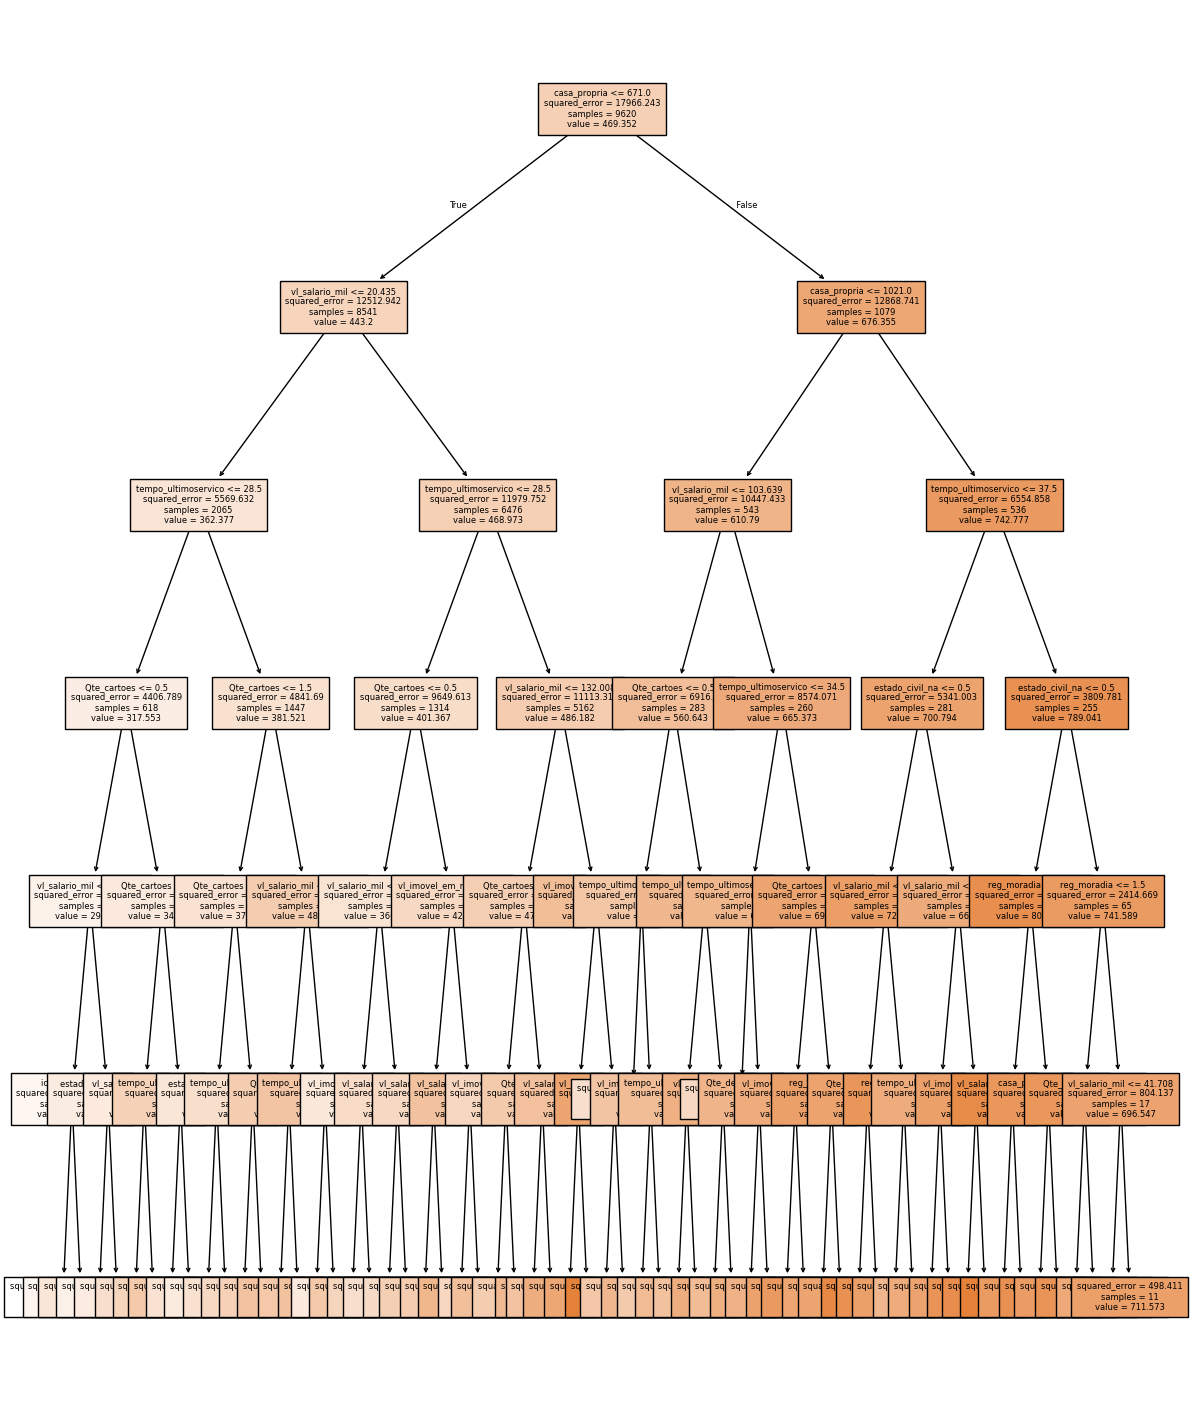

In [787]:

from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
input_features=['idade', 'sexo', 'escola', 'Qte_dependentes', 'tempo_ultimoservico',
       'trabalha', 'vl_salario_mil', 'reg_moradia', 'casa_propria',
       'vl_imovel_em_mil', 'Qte_cartoes', 'Qte_carros',
       'estado_civil_divorciado', 'estado_civil_na', 'estado_civil_solteiro']
fig = plt.figure(figsize=(14,18))
plot_tree(model_2, fontsize=6,filled=True, feature_names=input_features )

In [788]:
for caracteristica, score in zip(X_train, model_2.feature_importances_):
  print('caracteristica {} e Importância {}'.format(caracteristica, score*100))

caracteristica idade e Importância 0.04440049605796396
caracteristica sexo e Importância 0.0
caracteristica escola e Importância 0.0
caracteristica Qte_dependentes e Importância 0.07096415487525452
caracteristica tempo_ultimoservico e Importância 10.566446547839504
caracteristica trabalha e Importância 0.0
caracteristica vl_salario_mil e Importância 25.215823254115467
caracteristica reg_moradia e Importância 0.34617349802610275
caracteristica vl_imovel_em_mil e Importância 51.18582998174439
caracteristica Qte_cartoes e Importância 3.4429081242209336
caracteristica Qte_carros e Importância 8.367264724252843
caracteristica estado_civil_divorciado e Importância 0.04096901477919145
caracteristica estado_civil_na e Importância 0.0
caracteristica estado_civil_solteiro e Importância 0.7192202040883433


In [789]:
# Aplicando o algoritmo na base teste

y_test_regtree  = model_2.predict(X_test)

In [790]:
y_test_regtree

array([809.20535714, 488.16932166, 340.6916185 , 409.46666667,
       552.25806452, 409.46666667, 585.33484163, 409.46666667,
       488.16932166, 488.16932166, 388.88      , 645.99122807,
       409.46666667, 372.68908555, 380.76403448, 594.        ,
       334.0369112 , 340.6916185 , 430.30780886, 488.16932166,
       430.30780886, 473.340608  , 488.16932166, 534.54653107,
       430.30780886, 430.30780886, 585.33484163, 430.30780886,
       372.68908555, 372.68908555, 340.6916185 , 488.16932166,
       409.46666667, 534.54653107, 276.45721854, 372.68908555,
       462.24878049, 430.30780886, 488.16932166, 430.30780886,
       693.96907216, 430.30780886, 409.46666667, 809.20535714,
       488.16932166, 585.33484163, 430.30780886, 424.30866995,
       686.15833333, 430.30780886, 488.16932166, 409.46666667,
       430.30780886, 430.30780886, 534.54653107, 488.16932166,
       409.46666667, 488.16932166, 430.30780886, 636.548125  ,
       534.54653107, 326.25261538, 334.0369112 , 488.16

In [791]:
y_test

,SCORE_CREDITO
7659,745.0
5677,586.0
1374,214.2
1844,432.0
3595,809.1
...,...
4334,505.8
7076,461.7
8662,406.0
7289,762.0


In [792]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Arv_Regr  = (np.sqrt(mean_squared_error(y_test, y_test_regtree))).round(2)

print('Erro médio quadrático da Árvore de Regressão:',rmse_Arv_Regr  )


Erro médio quadrático da Árvore de Regressão: 80.95


In [793]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático da Regressão Linear:',rmse_Reg_lin )

Erro médio quadrático da Regressão Linear: 82.15


A Árvore de Regressão apresentou RMSE ligeiramente inferior ao da Regressão Linear (80,95 vs 82,15), indicando um pequeno ganho de capacidade preditiva. O resultado sugere a existência de relações não lineares entre algumas variáveis explicativas e o score de crédito. Entretanto, a diferença observada é pequena, indicando que ambos os modelos apresentam desempenho semelhante.

In [794]:
from sklearn.ensemble import RandomForestRegressor

In [795]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    random_state=17
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('R² Random Forest:', r2_score(y_test, y_pred_rf))
print('MAE Random Forest:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE Random Forest:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R² Random Forest: 0.6996954458126052
MAE Random Forest: 53.327526586732525
RMSE Random Forest: 70.87326733770445


In [796]:
import pandas as pd

importancias = pd.DataFrame({

    'Variavel': X_train.columns,

    'Importancia': rf.feature_importances_

}).sort_values('Importancia', ascending=False)

importancias

,Variavel,Importancia
8,vl_imovel_em_mil,0.460430
6,vl_salario_mil,0.257468
4,tempo_ultimoservico,0.123042
10,Qte_carros,0.079432
9,Qte_cartoes,0.048073
0,idade,0.013456
13,estado_civil_solteiro,0.007269
7,reg_moradia,0.003761
3,Qte_dependentes,0.002957
2,escola,0.001449


In [797]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('RMSE Random Forest:', rmse_rf)

RMSE Random Forest: 70.87326733770445


Foram comparados três modelos para previsão do score de crédito: Regressão Linear, Árvore de Regressão e Random Forest. A Regressão Linear apresentou RMSE de 82,15, enquanto a Árvore de Regressão reduziu ligeiramente o erro para 80,95. O melhor desempenho foi obtido pelo Random Forest, com RMSE de aproximadamente 70, representando uma redução de cerca de 15% no erro em relação à Regressão Linear. Os resultados indicam que existem relações não lineares e interações entre as variáveis explicativas que são melhor capturadas por modelos baseados em árvores.